# **Lab: Knowledge Distillation with Quantization and Deployment on Raspberry Pi**



## **Introduction**



In this lab, we will explore the concept of **knowledge distillation** in deep learning, which involves transferring the knowledge from a large, complex teacher model to a smaller, more efficient student model. Meanwhile, to further compress the model, we will apply **quantization techniques**—both integer and floating-point—to optimize the student model. Finally, we will deploy the student model on a real edge device, **Raspberry Pi**, for real-world applications.

The lab contains several parts, with a total of 100 points:
1. Teacher Model Implementation (20 pts)
2. Student Model Implementation (30 pts)
3. TensorFlow Lite Quantization (20 pts)
4. Experiments on Raspberry Pi (30 pts)

If you're using Colab, go to the settings menu (Runtime -> Change runtime type) and select GPU as the hardware accelerator. The best way to run your code is using Colab and it's free.

Same as Lab1 and Lab2, you need to solve 3 types of problems: coding, short-answer questions, and screenshots

- Coding: you only need to complete the section labeled as:  
```
    ##############################################################################
    # TODO
    ##############################################################################

    ##############################################################################
    # END OF TODO                               #
    ##############################################################################
```
- Question Answering: directly write your answer in the text blocks.
- Screenshot: You can upload screenshots to Google Drive or GitHub and link the URLs to text blocks, **OR** submit all your screenshots by a ZIP file.

---

**Please upload your ipynb file for Lab 3 to Brightspace. Name the file as `netid_lab_3.ipynb`(and `netid_lab_3_screenshots.zip` if you submit screenshots by seperate file). Ensure your submission before April 5th at 11:59 PM.**


## **Initialization**

In this section, we install and import all required dependencies. This cell sets up the environment to ensure that the necessary packages are available for the lab. Since we are using Google Colab, these commands will automatically install missing libraries.




In [1]:
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 31
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# **Knowledge Distillation: An Overview**
In the next chapter, you'll implement the teacher–student training loop using knowledge distillation. First, review the complete example below, which demonstrates how to define a custom Distiller class, and loss function. Then, you'll see a skeleton version with TODOs where you are required to fill in some key parts.


## **What is Knowledge Distillation?**
Knowledge distillation is a model compression technique where a **large, complex model (teacher)** transfers its learned knowledge to a **smaller, more efficient model (student)**. Instead of training the student model solely on ground-truth labels, distillation incorporates **soft labels**—the probability distributions output by the teacher. These soft labels provide additional information about the relationships between classes, making the student model more generalizable.

<img src="https://github.com/shawnyin128/NYU-EfficientAI-Materials/raw/master/graph/l26sp-lab3-1.png" width="800">

## **1. The Distillation Loss Function**

To effectively transfer knowledge, the student model is trained using a **distillation loss** that minimizes the difference between the teacher’s and student’s probability distributions. This is typically measured using **Kullback-Leibler (KL) divergence**.

### **Mathematical Formulation**
Let:
- $z_i^T$ and $z_i^S$ be the logits (pre-softmax outputs) from the teacher and student models for class $i$.

We introduce a **temperature factor** $T$, which smooths the probability distributions to create "softened" logits:

$$
\tilde{z}_i^T = z_i^T \Big/ T \quad \text{and} \quad \tilde{z}_i^S = z_i^S \Big/ T
$$

### **Softmax and Log-Softmax**

The teacher's and student's softened probability distributions are obtained using the **softmax function**:

$$
\tilde{p}_i = e^{\tilde{z}_i^T} \Big/ \sum_{j} e^{\tilde{z}_j^T}
$$

$$
\tilde{q}_i = e^{\tilde{z}_i^S} \Big/ \sum_{j} e^{\tilde{z}_j^S}
$$

Where:
- $\tilde{p}_i$ represents the teacher’s softened probability distribution.
- $\tilde{q}_i$ represents the student’s softened probability distribution.

In practical code implementations, to ensure numerical stability when calculating the loss, we often apply the **log-softmax** function to the student's logits to directly obtain $\log(\tilde{q}_i)$ instead of computing the raw probability first

### **KL Divergence Calculation**
The **KL divergence** measures the difference between these distributions:

$$
D_{KL}(\tilde{P} || \tilde{Q}) = \sum_{i} \tilde{p}_i \log \Big( \tilde{p}_i \Big/ \tilde{q}_i \Big)
$$

### **Final Distillation Loss**
The final **distillation loss** is:

$$
L_{\text{distill}} = T^2 \cdot D_{KL}(\tilde{P} || \tilde{Q})
$$

where the factor $T^2$ ensures that the gradients remain properly scaled after being divided by the temperature during the logit softening step.

---
## **2. Structure of the Distillation Process**

A knowledge distillation framework typically consists of two main components:

### **Teacher Model**
- A **pretrained, larger model** that has already been trained on the dataset.
- Provides **soft probability distributions** as supervision for the student.
- Remains **frozen** during student training.

### **Student Model**
- A **smaller, lightweight model** designed to approximate the teacher's behavior.
- Learns using a combination of **hard loss (cross entropy loss)** and **soft loss (distillation loss).**

The total loss function used to train the student is a **weighted sum** of these two losses:

$$
L_{\text{total}} = \alpha L_{\text{CrossEntropy}} + (1 - \alpha) L_{\text{Distill}}
$$

where:
- $ \alpha $ balances the contribution of the **cross entropy loss** (standard classification loss) and **distillation loss**.
- $ L_{\text{hard}} $ is the normal classification loss, such as cross-entropy.

---
## **3. High-Level Structure of a Distillation Framework**
The typical implementation follows this structure:

### **Step 1: Compute Teacher Predictions**
- The teacher model generates probability distributions $ P^{(T)} $.

### **Step 2: Compute Student Predictions**
- The student model generates probability distributions $ Q^{(T)} $.

### **Step 3: Compute Losses**
- Compute **cross entropy loss** using standard classification loss.
- Compute **distill loss** using KL divergence between teacher and student outputs.

### **Step 4: Update Student Model**
- Compute gradients with respect to the student model’s parameters.
- Optimize the student using a **gradient descent optimizer**.

---

**Recommended Readings and Resources**
For additional background and deeper insights into the techniques we’ll use, consider reviewing these online resources:
- [Distilling the Knowledge in a Neural Network](https://arxiv.org/abs/1503.02531)
- [Quantization of Deep Neural Networks for Efficient Inference](https://arxiv.org/abs/1712.05877)
- [TensorFlow Lite Model Optimization](https://www.tensorflow.org/lite/performance/model_optimization)
- [Getting Started with Raspberry Pi for Machine Learning](https://www.raspberrypi.org/documentation/usage/gpio/)[link text](https://)

 **Try implementing a distillation pipeline based on these principles!**

# **Knowledge Distillation : Teacher Model**

## What are teacher models ?


Teacher models are typically large, high-capacity neural networks that achieve high accuracy on complex datasets. In knowledge distillation, the teacher model serves as a reference from which a smaller, more efficient student model learns. Although the teacher model might be computationally heavy, its robust performance makes it ideal for guiding the training of the student model. In this lab, while we will eventually work with a Hybrid MircoViT architecture for the teacher model, here’s a sample implementation using a simpler Convolutional Neural Network (CNN) to illustrate the overall approach.

## Sample Teacher Model Implementation (Simple CNN)

In [2]:
# Define the simple teacher model
def simple_teacher_model(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile the teacher model
teacher_model = simple_teacher_model()
teacher_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Load and normalize CIFAR‑10 data
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# Train the teacher model
history = teacher_model.fit(train_images, train_labels,
                            epochs=5,
                            batch_size=64,
                            validation_data=(test_images, test_labels))

# Evaluate the model on the test data
test_loss, test_acc = teacher_model.evaluate(test_images, test_labels, verbose=2)
print("Test accuracy:", test_acc)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4813 - loss: 1.4468 - val_accuracy: 0.5948 - val_loss: 1.1626
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6248 - loss: 1.0685 - val_accuracy: 0.6448 - val_loss: 1.0061
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6769 - loss: 0.9266 - val_accuracy: 0.6665 - val_loss: 0.9427
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7100 - loss: 0.8346 - val_accuracy: 0.6862 - val_loss: 0.9017
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7378 - loss: 0.7583 - val_accuracy: 0.6924 - val_loss: 0.8982
313/313 - 1s - 4ms/step - accuracy: 0.6924 - loss: 0.8982
Test accuracy: 0.6923999786376953


### Evaluating the Sample Teacher Model Performance

Our simple CNN teacher model achieved about **65% - 70% accuracy** on CIFAR-10. For effective knowledge distillation, it's crucial to have a high-performing teacher because:

- **Enhanced Guidance:** A more accurate teacher provides richer and more reliable soft targets for the student.
- **Better Representations:** High accuracy suggests that the teacher has learned robust feature representations, which are vital for the student to mimic.
- **Performance Benchmark:** A significant performance gap between teacher and student drives the student to learn and improve.

In our next steps, we will work on refining the teacher model to ensure it sets a strong foundation for the student model.


# **Teacher Model Implementation (20 pts Total)**

> ### **You need to achieve accuracy of atleast 85 percent for the Teacher Model**

<img src="https://github.com/shawnyin128/NYU-EfficientAI-Materials/raw/master/graph/l26sp-lab3-2.png" width="800">

The provided skeleton is a lightweight version of **$ViT_C$** from [Early Convolutions Help Transformers See Better
](https://arxiv.org/pdf/2106.14881). Hybrid ViTs combine the advantages of CNN and ViT. In particular, the CNN stem of $ViT_C$ increases optimization stability and also improves peak performance.



## Section 1: Transformer Block (5 pts)

In [3]:
def mlp(x, hidden_units, dropout_rate):
    """Provided MLP block for the Transformer"""
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

def transformer_block(inputs, projection_dim, num_heads, mlp_dim, dropout_rate=0.1):
    epsilon = 1e-6
    ##############################################
    # TODO
    ##############################################
    # Apply Layer Normalization to the inputs
    x1 = layers.LayerNormalization(epsilon=epsilon)(inputs)

    # Create a Multi-Head Attention layer and pass x1 through it
    # Apply it as Self-Attention (query, key, and value are all x1).
    mha_layer = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)
    x2 = mha_layer(query=x1, key=x1, value=x1)

    # Add the first shortcut connection
    shortcut1 = layers.Add()([inputs, x2])

    # Apply another Layer Normalization to x2
    x3 = layers.LayerNormalization(epsilon=epsilon)(shortcut1)

    # Apply the MLP block to x3 (use the provided mlp function)
    # hidden_units must be a list to ensure residual shape matching.
    x4 = mlp(x3, [mlp_dim, projection_dim], dropout_rate)

    # TODO: Add the second shortcut connection and return
    shortcut2 = layers.Add()([shortcut1, x4])

    out = shortcut2
    ##############################################
    # End of TODO
    ##############################################
    return out

## Section 2: Hybrid ViT Model (10 pts)

In [4]:
def HybridViT(input_shape=(32, 32, 3), num_classes=10,
                   projection_dim=128, num_heads=4,
                   transformer_layers=4, mlp_dim=256):

    inputs = layers.Input(shape=input_shape)
    padding = "same"
    use_bias = False
    num_patches = 64
    epsilon = 1e-6

    ######################################################
    # TODO
    ######################################################
    he_init = tf.keras.initializers.HeNormal()

    # -------------------- Conv Stem ---------------------
    # NOTE: Except the final conv, you should add BatchNorm and ReLU
    # 1st Conv (64 channels, 3x3 kernel, stride 2)
    layer1 = layers.Conv2D(64, kernel_size=3, strides=2, padding=padding, use_bias=use_bias, kernel_initializer=he_init)(inputs)
    bn1 = layers.BatchNormalization(epsilon=epsilon)(layer1)
    relu1 = layers.ReLU()(bn1)

    # 2nd Conv (64 channels, 3x3 kernel, stride 1)
    layer2 =  layers.Conv2D(64, kernel_size=3, strides=1, padding=padding, use_bias=use_bias, kernel_initializer=he_init)(relu1)
    bn2 = layers.BatchNormalization(epsilon=epsilon)(layer2)
    relu2 = layers.ReLU()(bn2)

    # 3rd Conv (128 channels, 3x3 kernel, stride 2)
    layer3 = layers.Conv2D(128, kernel_size=3, strides=2, padding=padding, use_bias=use_bias, kernel_initializer=he_init)(relu2)
    bn3 = layers.BatchNormalization(epsilon=epsilon)(layer3)
    relu3 = layers.ReLU()(bn3)

    # TODO: 4th Conv (128 channels, 3x3 kernel, stride 1)
    layer4 = layers.Conv2D(128, kernel_size=3, strides=1, padding=padding, use_bias=use_bias, kernel_initializer=he_init)(relu3)
    bn4 = layers.BatchNormalization(epsilon=epsilon)(layer4)
    relu4 = layers.ReLU()(bn4)

    # TODO: last Conv (projection_dim, 1x1 kernel, stride 1)
    layer5 = layers.Conv2D(projection_dim, kernel_size=1, strides=1, padding=padding, use_bias=use_bias, kernel_initializer=he_init)(relu4)

    x = layer5

    ######################################################
    # End of TODO
    ######################################################

    # Positional embedding
    encoded_patches = layers.Reshape((num_patches, projection_dim))(x)
    positions = tf.range(start=0, limit=num_patches)
    position_embedding = layers.Embedding(
        input_dim=num_patches, output_dim=projection_dim
    )(positions)
    encoded_patches = encoded_patches + position_embedding

    ######################################################
    # TODO
    ######################################################
    # Stack transformer layers
    for _ in range(transformer_layers):
        encoded_patches = transformer_block(encoded_patches, projection_dim, num_heads, mlp_dim)

    ######################################################
    # End of TODO
    ######################################################

    representation = layers.LayerNormalization(epsilon=epsilon)(encoded_patches)
    representation = layers.GlobalAveragePooling1D()(representation)
    outputs = layers.Dense(num_classes, activation='softmax')(representation)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

## Section 3: Compile and Train (5 pts)

In [5]:
# Provided: load your model
teacher_model = HybridViT()

# Provided: Optimzier AdamW
teacher_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Provided: Load and normalize CIFAR‑10 data
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# Provided: Set up data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    zoom_range=0.1
)

datagen.fit(train_images)

# Provided: Training Config
batch_size = 128
epochs = 30
##############################################
# TODO
##############################################
# Calculate how many steps are in one epoch
steps_per_epoch = len(train_images) // batch_size

# Create the generator to pull batches from
train_gen = datagen.flow(train_images, train_labels, batch_size=batch_size)

# Loss Function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

# Cosine learning-rate schedule parameters
initial_lr = 1e-3
min_lr = 1e-5
total_steps = epochs * steps_per_epoch
global_step = 0

# Best-checkpoint / early stopping
best_acc = 0.0
best_weights = None
patience = 5
wait = 0

# Train your model using the augmented data
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")

    for step in range(steps_per_epoch):
        # Manual cosine decay
        cosine_decay = 0.5 * (1 + np.cos(np.pi * global_step / total_steps))
        current_lr = min_lr + (initial_lr - min_lr) * cosine_decay
        teacher_model.optimizer.learning_rate.assign(current_lr)

        # Pull a batch of augmented data
        x_batch, y_batch = next(train_gen)

        with tf.GradientTape() as tape:
          preds  = teacher_model(x_batch, training=True)
          loss = loss_fn(y_batch, preds )

        grads = tape.gradient(loss, teacher_model.trainable_weights)
        teacher_model.optimizer.apply_gradients(zip(grads, teacher_model.trainable_weights))

        # Log every 100 batches
        if step % 100 == 0:
            batch_preds = tf.argmax(preds, axis=1, output_type=tf.int32)
            batch_labels = tf.reshape(tf.cast(y_batch, tf.int32), [-1])
            batch_acc = tf.reduce_mean(
                tf.cast(tf.equal(batch_preds, batch_labels), tf.float32)
            )
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Step {step + 1}/{steps_per_epoch} | "
                f"LR: {float(current_lr):.6f} | "
                f"Batch loss: {float(loss):.4f} | "
                f"Batch acc: {float(batch_acc) * 100:.2f}%"
            )

        global_step += 1

    # Epoch-end validation accuracy
    val_loss, val_acc = teacher_model.evaluate(test_images, test_labels, verbose=0)
    print(
        f"End of epoch {epoch + 1} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc * 100:.2f}%", "\n"
    )

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_weights = teacher_model.get_weights()
        wait = 0
        print(f"New best model: {best_acc * 100:.2f}%")
    else:
        wait += 1
        print(f"No improvement for {wait} epoch(s)")

    # Early stopping
    if wait >= patience:
        print("Early stopping triggered.")
        break

# Restore best weights before the provided save() cell runs
if best_weights is not None:
    teacher_model.set_weights(best_weights)
    print(f"Restored best model with accuracy: {best_acc * 100:.2f}%")
##############################################
# End of TODO
##############################################



Epoch 1/30
Epoch 1/30 | Step 1/390 | LR: 0.001000 | Batch loss: 2.4003 | Batch acc: 14.06%
Epoch 1/30 | Step 101/390 | LR: 0.001000 | Batch loss: 1.6882 | Batch acc: 35.16%
Epoch 1/30 | Step 201/390 | LR: 0.000999 | Batch loss: 1.4222 | Batch acc: 41.41%
Epoch 1/30 | Step 301/390 | LR: 0.000998 | Batch loss: 1.2872 | Batch acc: 51.56%
End of epoch 1 | Val loss: 1.5173 | Val acc: 46.96% 

New best model: 46.96%
Epoch 2/30
Epoch 2/30 | Step 1/390 | LR: 0.000997 | Batch loss: 1.0965 | Batch acc: 58.75%
Epoch 2/30 | Step 101/390 | LR: 0.000996 | Batch loss: 1.0795 | Batch acc: 57.03%
Epoch 2/30 | Step 201/390 | LR: 0.000994 | Batch loss: 1.1715 | Batch acc: 56.25%
Epoch 2/30 | Step 301/390 | LR: 0.000992 | Batch loss: 1.1448 | Batch acc: 56.25%
End of epoch 2 | Val loss: 1.0422 | Val acc: 63.43% 

New best model: 63.43%
Epoch 3/30
Epoch 3/30 | Step 1/390 | LR: 0.000989 | Batch loss: 1.0863 | Batch acc: 63.28%
Epoch 3/30 | Step 101/390 | LR: 0.000986 | Batch loss: 0.9893 | Batch acc: 60.94%

In [6]:
test_loss, test_acc = teacher_model.evaluate(test_images, test_labels, verbose=1)
print(f"Test accuracy: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8529 - loss: 0.4593
Test accuracy: 85.29%


## Section 4: Save the Trained Model

In [8]:
teacher_model.save('teacher_model.keras')
print("Teacher Model Trained and Saved.")

Teacher Model Trained and Saved.


# **Student Model Implementation (30 pts Total)**

> ### **Make sure you acheive 70% accuracy for student model after distillation**




## Section 1: Load the Teacher Model

Make sure you have saved the `teacher_model.keras` you just trained from previous part. In this section, we load the teacher model and freeze its weights because we won't train it further.


In [9]:
# Make sure you have "teacher_model.keras" in your working directory.
teacher_model = tf.keras.models.load_model("teacher_model.keras")
teacher_model.trainable = False  # Freeze the teacher model


## Section 2. Create the Student Model

Here, we define a lightweight student model using MobileNetV2. The student model will be trained using knowledge distillation.


In [10]:
from tensorflow.keras.applications import MobileNetV2
def create_student_model():
    """
    Create a lightweight student model based on MobileNetV2.
    You can modify or extend this architecture as needed.
    """
    # Use MobileNetV2 as the base model without pre-trained weights.
    base_model = MobileNetV2(weights=None, include_top=False, input_shape=(32, 32, 3))
    x = layers.GlobalAveragePooling2D()(base_model.output)
    # modify or add extra layers.
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

student_model = create_student_model()


## Section 3: Define the Distiller (20 pts)

The distiller class handles the custom training loop for knowledge distillation. It calculates a combined loss from:
- **Hard Loss:** The standard cross entropy loss between the student's predictions and the true labels.
- **Soft Loss:** The distillation loss between the teacher’s and student's predictions (using KL divergence).

Complete the TODOs to implement the missing parts.


In [20]:
class Distiller(tf.keras.Model):
    """
    Handles the custom training loop for knowledge distillation:
    - Uses teacher predictions (soft targets).
    - Uses student predictions.
    - Calculates a combined loss (hard + soft).
    """
    def __init__(self, student, teacher):
        super(Distiller, self).__init__()
        self.student = student
        self.teacher = teacher

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super(Distiller, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # Obtain teacher predictions (teacher is frozen)
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
        ##############################################
        # TODO
        ##############################################
            # Compute student predictions for x.
            student_predictions = self.student(x, training=True)

            # Compute the cross entropy loss (hard loss)
            student_loss = self.student_loss_fn(y, student_predictions)

            # Compute the distillation loss (soft loss)
            distillation_loss = self.distillation_loss_fn(teacher_predictions, student_predictions, self.temperature)

            # Combine the two losses (hard and soft)
            loss = (self.alpha * student_loss) + ((1 - self.alpha) * distillation_loss)

        # Compute gradients and update the student model's trainable variables.
        gradients = tape.gradient(loss, self.student.trainable_variables)
        ##############################################
        # End of TODO
        ##############################################
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))

        # Update metrics
        self.compiled_metrics.update_state(y, student_predictions)
        results = {m.name: m.result() for m in self.metrics}
        results["loss"] = loss
        return results

    def test_step(self, data):
        x, y = data
        ##############################################
        # TODO
        ##############################################
        # Compute student predictions in inference mode.
        y_pred = self.student(x, training=False)

        # Compute the student loss comparing y_pred to y.
        student_loss = self.student_loss_fn(y, y_pred)
        ##############################################
        # End of TODO
        ##############################################

        # Update metrics
        self.compiled_metrics.update_state(y, y_pred)
        results = {m.name: m.result() for m in self.metrics}
        results["loss"] = student_loss
        return results



## Section 4: Define Loss Functions (10 pts)

Define the loss functions used in the distillation process:
- **Cross Entropy Loss:** Standard loss between student predictions and true labels.
- **Distillation Loss:** Uses KL divergence to measure the difference between the softened predictions of the teacher and student.


In [19]:
# Hard label loss (student vs. ground truth)
student_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

# Distillation loss function (KL divergence)
def distillation_loss_fn(teacher_logits, student_logits, temperature):
    """
    Compute the distillation loss using KL divergence.
    """
    epsilon = 1e-7
    ##############################################
    # TODO
    ##############################################
    teacher_log_probs = tf.math.log(tf.clip_by_value(teacher_logits, epsilon, 1.0))
    student_log_probs_raw = tf.math.log(tf.clip_by_value(student_logits, epsilon, 1.0))

    # Compute teacher probabilities using softmax with temperature scaling.
    teacher_probs = tf.nn.softmax(teacher_log_probs / temperature, axis=1)
    teacher_probs = tf.stop_gradient(teacher_probs)

    # Compute student log-probabilities using log-softmax with temperature scaling.
    student_log_probs = tf.nn.log_softmax(student_log_probs_raw / temperature, axis=1)

    # Compute the KL divergence loss and return it.
    KL_per_sample = teacher_probs * (tf.math.log(teacher_probs + epsilon) - student_log_probs)
    KL_per_sample = tf.reduce_sum(KL_per_sample, axis=1)

    k = tf.reduce_mean(KL_per_sample) * (temperature ** 2)
    ##############################################
    # End of TODO
    ##############################################

    return k


## Section 5. Compile & Train the Distiller

In this final section, we create an instance of the Distiller, compile it, and train it using the CIFAR-10 dataset. Optionally, data augmentation is applied.


In [21]:
# Create the Distiller instance.
distiller = Distiller(student=student_model, teacher=teacher_model)

# Compile the distiller.
distiller.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
    student_loss_fn=student_loss_fn,
    distillation_loss_fn=distillation_loss_fn,
    alpha=0.3,       # Weight for the hard loss
    temperature=3    # Temperature for softening teacher predictions
)

# Load and normalize CIFAR-10 dataset.
from tensorflow.keras.preprocessing.image import ImageDataGenerator
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# Optional: Data augmentation.
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(train_images)

# Train the distiller using the data generator.
distiller.fit(
    datagen.flow(train_images, train_labels, batch_size=128),
    epochs=15,
    validation_data=(test_images, test_labels)
)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:670: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


391/391 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - sparse_categorical_accuracy: 0.6365 - loss: 1.5532 - val_loss: 0.8622
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - sparse_categorical_accuracy: 0.6074 - loss: 1.5084 - val_loss: 1.9309
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - sparse_categorical_accuracy: 0.5811 - loss: 1.3517 - val_loss: 3.9845
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - sparse_categorical_accuracy: 0.5745 - loss: 1.2562 - val_loss: 2.8921
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - sparse_categorical_accuracy: 0.6753 - loss: 1.2259 - val_loss: 1.4357
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - sparse_categorical_accuracy: 0.6935 - loss: 1.0906 - val_loss: 1.7807
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - sparse_categorical_accuracy: 0.5749 - loss: 1.1741 - val_loss: 3.9391
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - sparse_categorical_accuracy: 0.5890 - loss: 1.0083 - val_loss: 2.3435
Ep

In [22]:
results = distiller.evaluate(test_images, test_labels, verbose=1, return_dict=True)
print(f"Student test accuracy: {results['compile_metrics']['sparse_categorical_accuracy'].numpy() * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - sparse_categorical_accuracy: 0.7513 - loss: 0.8212
Student test accuracy: 75.13%


## Section 6: Save distilled student model

In [15]:
# Save the distilled student model
student_model.save("student_model.h5")
print("Student model saved.")

Student model saved.


# **TensorFlow Lite Quantization (20 pts Total)**

In this section, we convert the saved student model to TensorFlow Lite format using two different quantization methods:
- **Float16 Weight-Only Quantization:** Converts model weights from float32 to float16.
- **INT8 Weight-Only Quantization:** Converts model weights to int8 using a representative dataset for calibration while keeping activations in float32.

Review the code, then complete the TODO sections with appropriate settings or modifications as needed.

HINT: You might find [TensorFolow Lite's PTQ Guide](https://ai.google.dev/edge/litert/conversion/tensorflow/quantization/post_training_quantization) very helpful


## Section 1: FP16 Quantization (10 pts)

In [16]:
# Load the student model from a saved Keras model file.
student_model = tf.keras.models.load_model('student_model.h5')

##############################################
# TODO
##############################################
# Create a TFLite converter from the student model.
converter = tf.lite.TFLiteConverter.from_keras_model(student_model)

# Set the converter optimizations to enable model compression.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Define the target data type for quantization
# PS: float16 for weight-only quantization.
converter.target_spec.supported_types = [tf.float16]

# Convert the model to TFLite format.
tflite_model = converter.convert()
##############################################
# End of TODO
##############################################

# Save the converted TFLite model to a file.
with open('student_model_float16_weights_only.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpcozhs0iq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136222413796560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136223256911440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136223256907600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136222413836880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136223256912976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136223769008016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136223769010704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136223769008592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136223769013200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136223769013008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13622376901243

## Section 2: INT8 Quantization (10 pts)

Key Differences from FP16 Quantization
- **Calibration**: Since the range of INT8 is too small, we need a calibration dataset to measure the min/max activation ranges, ensuring accurate FP-to-INT8 mapping.
- **FP32 input/output**: Unlike FP16, full INT8 conversion might have default integer input/output tensors. We explicitly force them back to FP32 so the model remains compatible with our existing float image preprocessing.


In [17]:
# Load the CIFAR-10 test dataset for calibration.
(_, _), (test_images, _) = tf.keras.datasets.cifar10.load_data()
test_images = test_images.astype(np.float32) / 255.0

# A representative dataset generator for calibration.
def representative_data_gen():
    # Verify if 100 images are sufficient for calibration or adjust the count.
    for i in range(100):
        yield [test_images[i:i+1]]

# Load the student model from a saved Keras model file.
student_model = tf.keras.models.load_model('student_model.h5')

##############################################
# TODO
##############################################
# Create a TFLite converter from the student model.
converter = tf.lite.TFLiteConverter.from_keras_model(student_model)

# Set the converter optimizations for weight quantization.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Assign the representative dataset generator for calibration.
converter.representative_dataset = representative_data_gen

# Set the target operations to use only INT8 built-in ops.
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Keep activations as float32 for compatibility.
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

# Convert the model to TFLite format.
tflite_model = converter.convert()
##############################################
# End of TODO
##############################################

# Save the converted TFLite model to a file.
with open('student_model_int8_weights_only_cifar.tflite', 'wb') as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmppk4q70_u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136219775430160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775434576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775427472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775429776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775434192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775429968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775429200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775434384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775430352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136219775433232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13621977543380

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


# **Raspberry Pi Setup**
> Take and keep your screenshots for submission in next chaper




In this section, we will set up a Raspberry Pi 4 server through [Mythic Beasts](https://www.mythic-beasts.com/order/rpi/). This server will be used to deploy and run our quantized TensorFlow Lite models. Follow the steps below to get started.

## Prepare and Connect to Server
### 1. Purchase a Raspberry Pi 4 Server (approx 7-10 pounds)
- Go to [Mythic Beasts Raspberry Pi](https://www.mythic-beasts.com/order/rpi/).
- Choose the **Raspberry Pi 4 with at least 4GB RAM** monthly plan.
- Complete the checkout process to finalize your purchase.

### 2. Name Your Server
- During setup, you will have the option to name your server.
- **Important:** Use the format `netid_lab3` to clearly identify your server for this lab.
- Verify that the name is correct before proceeding.

### 3. Generate SSH Keys
To securely connect to your Raspberry Pi server, you will need SSH keys:

- Open a terminal (on macOS/Linux) or use Git Bash/PowerShell (on Windows).
- Generate a new SSH key pair (if you don’t already have one) by running:

  ```bash
  ssh-keygen -t rsa -b 4096
  ```

<img src="https://github.com/shawnyin128/NYU-EfficientAI-Materials/raw/master/graph/l26sp-lab3-3.png" width="600">

### 4. Add Your SSH Public Key to Mythic Beasts
- Log in to **Mythic Beasts** and access `https://www.mythic-beasts.com/customer/servers/rpi/`+ Name of Your Machine
- Click the **Congifure Keys** following the blue arrow in the picture.
- Paste the **public** portion of your SSH key (the content of `~/.ssh/id_rsa.pub` or equivalent) into the key field.
- Save the changes.

### 5. Connect to Your Raspberry Pi ( Mac )
Once your server is set up and the SSH keys are in place:

- **Copy the ssh command** to access to your Raspberry Pi server following the blue arrow in the picture.
- Open a terminal and connect via SSH:

   ```bash
   ssh -p 5244 <username>@<your_pi_server_ip>

## Setup Server Environment
1. **Set the Time:**
If the initial device time is incorrect, you will be unable to use network-based tools like wget and apt. Therefore, you may need to manually set it to the correct time.
    ```bash
    date -s "$(wget -qSO- --max-redirect=0 google.com 2>&1 | grep Date: | cut -d' ' -f5-8)Z"
    ```
2. **Install Packages:**
Install the required python modules. Due to the PEP668 restriction on the device, tflite-runtime must be installed in the user directory using the parameters below. Alternatively, you can use venv, which is a more elegant method.
    ```
    apt install python3-pip python3-pil python3-numpy python3-psutil libopenjp2-7 libopenblas0
    pip install tflite-runtime --break-system-packages
    ```
3. **Miscellaneous:**
Different devices may encounter different minor issues during configuration. Please read the error messages carefully, follow the system's prompts to install supplemental dependencies, or contact the TA.

## **Transferring Files to Server**

To transfer files from your local machine to a Raspberry Pi hosted by Mythic Beasts, use the `scp` command and the port of your own configuration.

### Command Format

```sh
scp -P 5244 "/path/to/local/file" root@ssh.your-hostedpi.com:/path/to/destination/
```
### Example Command
``` sh
scp -P 5244 "~/Documents/my_script.py" root@ssh.examplepi.com:/home/pi/
```
### Important Instructions:
- Check the **port** of the configuration of your own server.
- Ensure that the file transfer completes **100%** before proceeding.
- If the `scp` command is interrupted or incomplete, your files may be **corrupted**, leading to runtime errors.
- Always **wait for the command to fully execute** before disconnecting.

## **NOTE** :
For now transfer both the **"student_model_int8_weights_only_cifar.tflite"** and **"student_model_float16_weights_only.tflite"** to the raspberry pi using SCP command. The above setup was for macos it follows similarly for windows systems as well you can find it online i.e (how to setup scp,ssh etc ).

In [25]:
import os

print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'teacher_model.keras', 'student_model_int8_weights_only_cifar.tflite', 'student_model.h5', 'student_model_float16_weights_only.tflite', 'sample_data']


In [26]:
from google.colab import files

files.download("/content/student_model_float16_weights_only.tflite")
files.download("/content/student_model_int8_weights_only_cifar.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Experiments on Raspberry Pi (30 pts Total)

## Downloading Images on Server
Run the following code on raspberry pi

In [ ]:
# NOTE: Do not run this on Colab
mkdir -p images
wget -O images/image1_frog.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog1.png
wget -O images/image2_automobile.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile1.png
wget -O images/image3_truck.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck1.png
wget -O images/image4_airplane.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane1.png
wget -O images/image5_ship.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship1.png
wget -O images/image6_deer.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer1.png
wget -O images/image7_dog.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog1.png
wget -O images/image8_horse.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse1.png
wget -O images/image9_bird.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird1.png
wget -O images/image10_cat.jpg https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat1.png


## **Screenshots of Your Setup (10 pts)**

Your submission should include the following screenshots:

1. **Server Displaying Your NetID (`netid_lab3`)**  
   - Show the terminal where your server is named as `netid_lab3`.

2. **SSH Login Screenshot**  
   - A terminal screenshot where you are logged into your server via SSH.

3. **`wget` Command for Downloading Images**  
   - A screenshot showing the execution of the `wget` command to download the required images.

4. **SCP Command for Transferring `.tflite` Models to the PO**  
   - Use the following command to transfer your TensorFlow Lite models from your local machine to the Pi:  



Your screenshots:

### 1. Server Displaying NetID
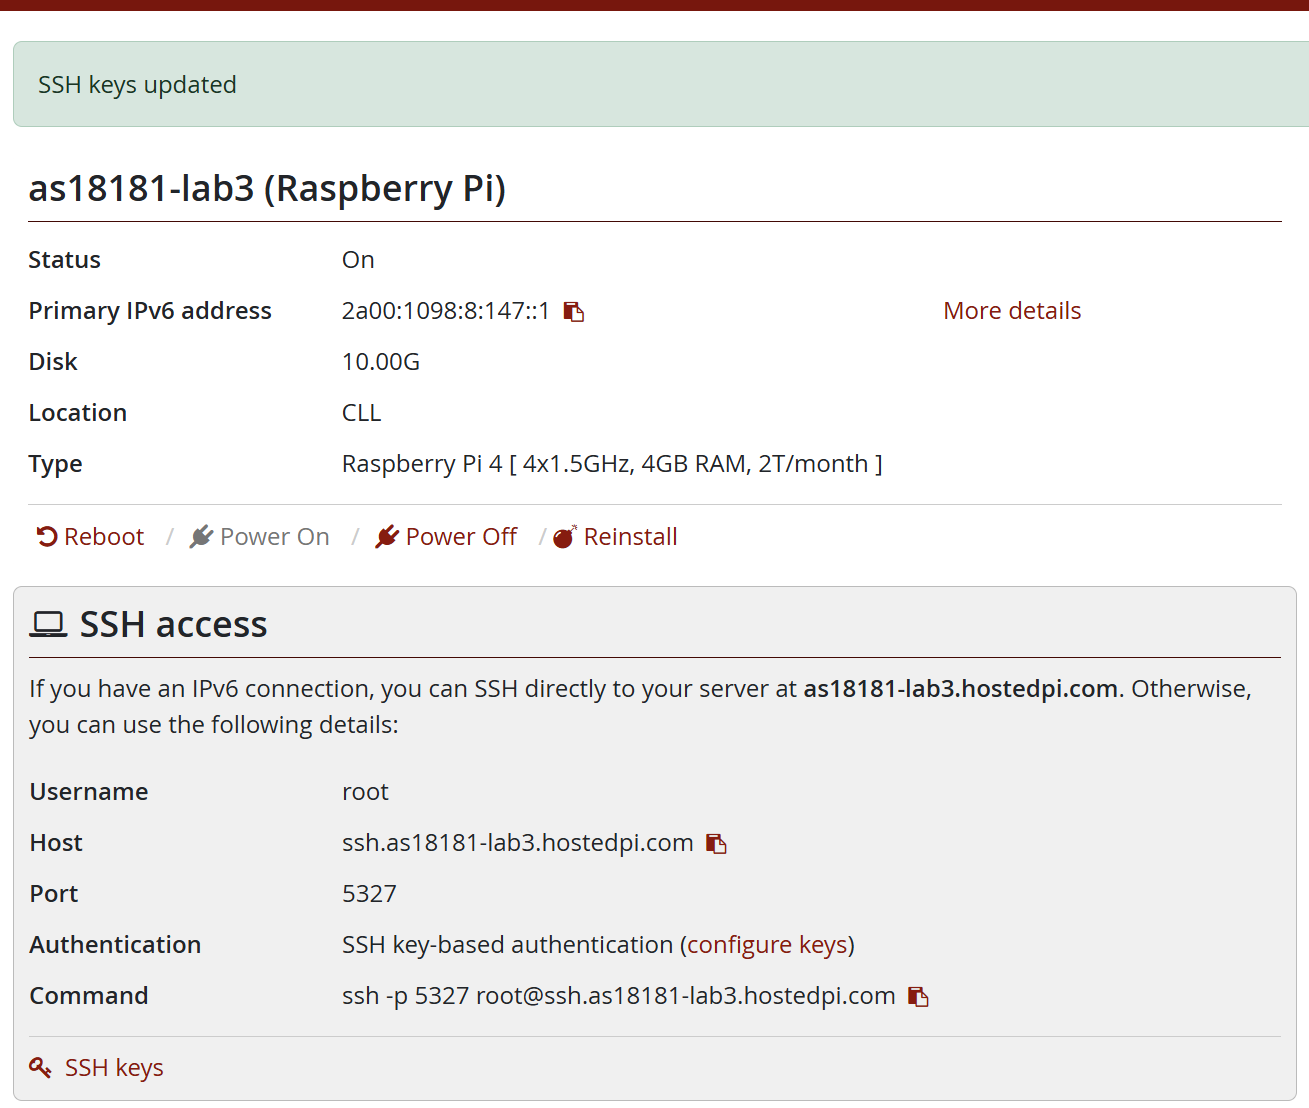

### 2. SSH Login
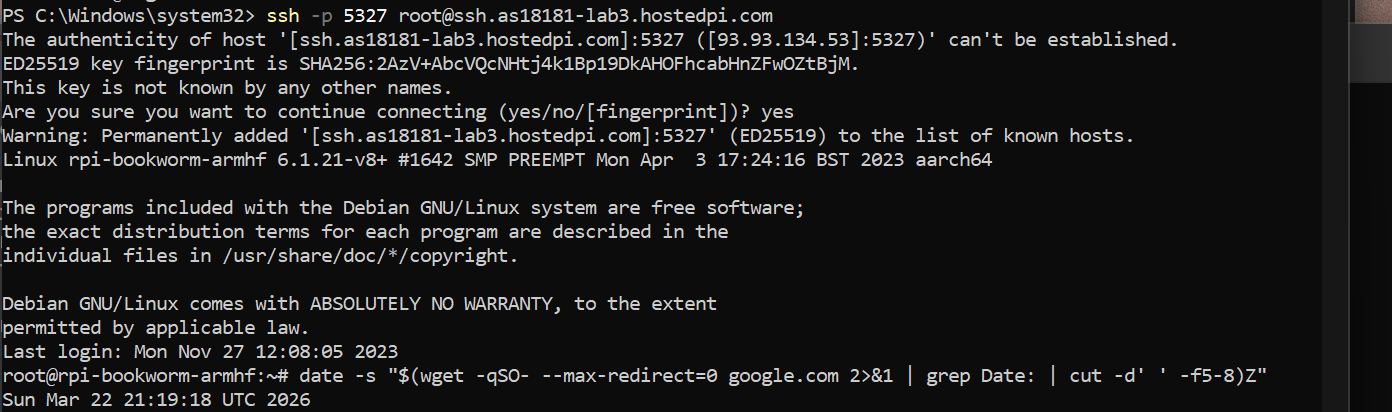

### 3.1 wget Command 1
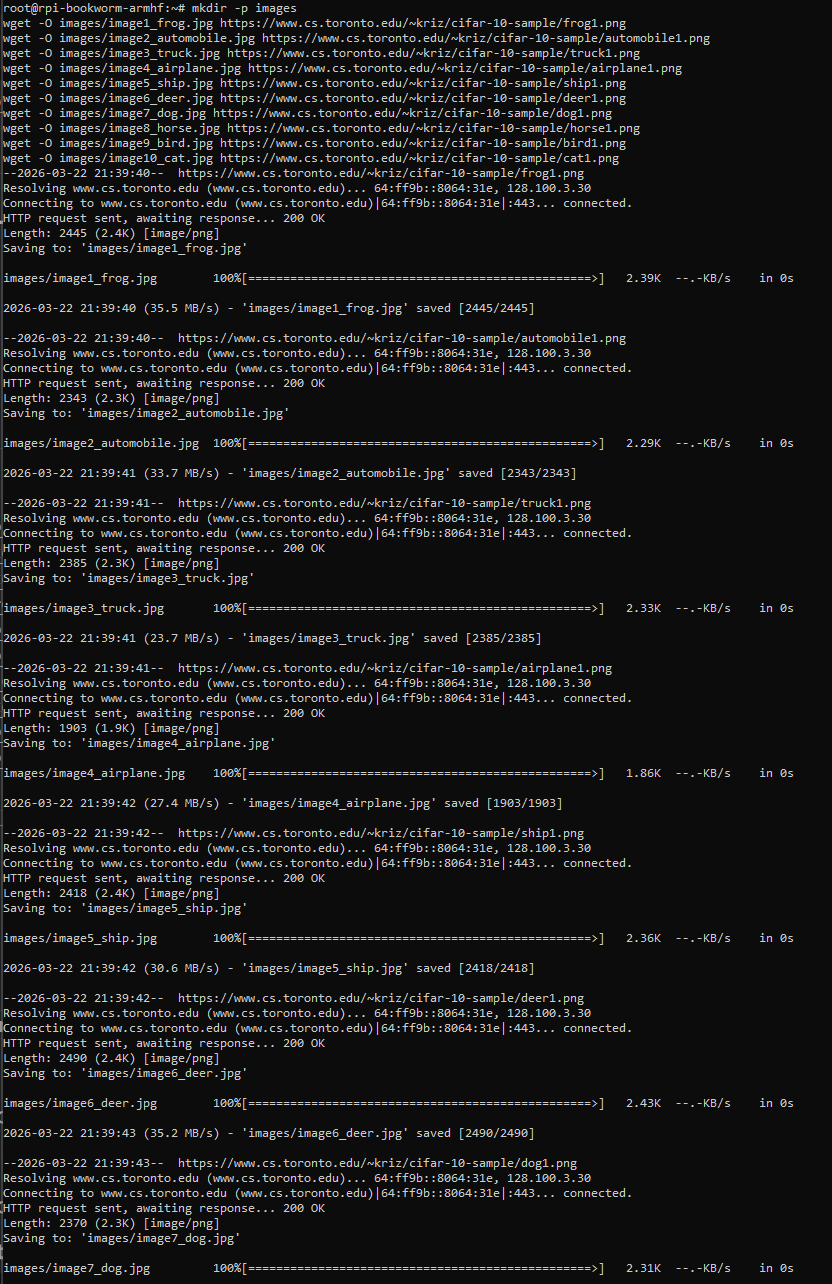

### 3.2 wget Command 2
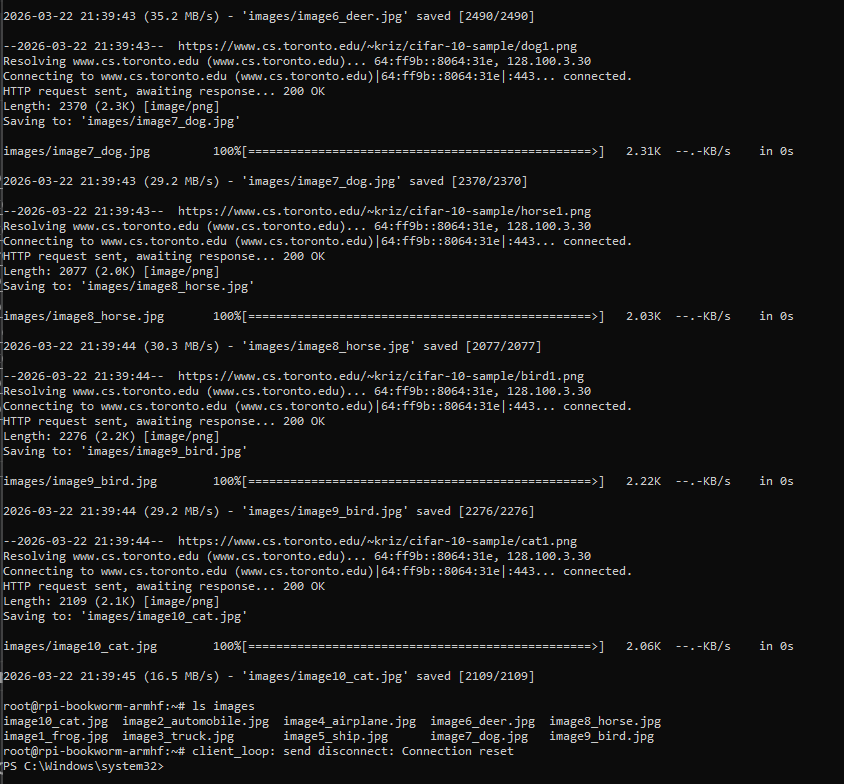

### 4. SCP Command
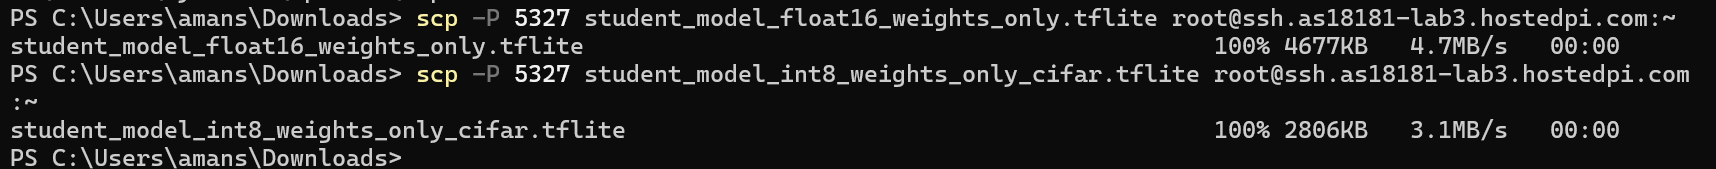

## **Running Inference on Server** (10 pts)
After transferring the **TFLite models** and downloading the **images**, the next step is to **run inference** using the `Inference.py` script.

---

### **Setup Requirements**
Ensure that:
- The **quantized models** (`student_model_float16_weights_only.tflite`, `student_model_int8_weights_only_cifar.tflite`) are in the working directory.
- The **test images** are inside the `images/` folder.
- The required **libraries** (`tflite_runtime`, `PIL`, `numpy`, `psutil`, `shutil`) are installed.

---

### **Implement & Transfer Inference Script**
Now, complete the **TODOs in `Inference.py`** to:
- Load the **TFLite models**.
- Preprocess images and run inference.
- Measure CPU, memory, and temperature usage.

Once completed, **transfer `Inference.py` to the Raspberry Pi using SCP** and run inference to analyze performance.

 **Complete the script, transfer it, and start running inference!**

---
PS: You can run the `reference.py` on Colab after minor modification to verify your results


In [ ]:
from tflite_runtime.interpreter import Interpreter
from PIL import Image
import numpy as np
import time
import os
import psutil
import shutil

# List of models to test
models = [
    "student_model_float16_weights_only.tflite",
    "student_model_int8_weights_only_cifar.tflite"
]

# Path to images folder
image_folder = "images/"
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))])

# Ensure images exist
if not image_files:
    print("No images found in the 'images/' folder. Please add images before running inference.")
    exit()

# Function to get CPU temperature
def get_cpu_temp():
    try:
        with open("/sys/class/thermal/thermal_zone0/temp", "r") as f:
            return int(f.read().strip()) / 1000.0  # Convert from millidegrees to Celsius
    except Exception:
        return None

# Function to preprocess images
def preprocess_image(image_path, input_shape, dtype=np.float32):
    """Load and preprocess an image to match the model's expected input shape."""
    img = Image.open(image_path).resize((input_shape[1], input_shape[2]))
    img_array = np.array(img).astype(dtype) / 255.0  # Normalize

    # INT8 models require int8 inputs, so scale correctly
    if dtype == np.int8:
        img_array = (img_array * 255 - 128).astype(np.int8)

    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# -------------------------------
# Function to run inference
# -------------------------------

def run_inference(model_path, image_path):
    """Run inference on a quantized TFLite model and collect performance data."""
    try:
        ##############################################
        # TODO
        ##############################################
        # 1) Load the TFLite model using the Interpreter.
        interpreter = Interpreter(model_path=model_path)

        # 2) Allocate memory for model tensors.
        interpreter.allocate_tensors()

        # 3) Retrieve model input and output tensor details.
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        # 4) Extract input shape and data type.
        input_shape = input_details[0]['shape']
        input_dtype = input_details[0]['dtype']

        # 5) Load and preprocess the image to match the model’s input format.
        sample_input = preprocess_image(image_path, input_shape, input_dtype)

        # 6) Measure CPU and memory usage before inference using psutil
        cpu_before = psutil.cpu_percent(interval=None)
        mem_before = psutil.virtual_memory().percent
        temp_before = get_cpu_temp()

        # 7) Perform inference
        start_time = time.time()
        interpreter.set_tensor(input_details[0]["index"], sample_input)
        interpreter.invoke()
        end_time = time.time()

        # 8) Retrieve the output tensor from the model.
        output_data = interpreter.get_tensor(output_details[0]['index'])

        # 9) Determine the predicted class from the output.
        predicted_class = int(np.argmax(output_data, axis=1)[0])

        # 10) Measure CPU and memory usage after inference.
        cpu_after = psutil.cpu_percent(interval=None)
        mem_after = psutil.virtual_memory().percent
        temp_after = get_cpu_temp()
        ##############################################
        # End of TODO
        ##############################################

        return {
            "model": model_path,
            "image": os.path.basename(image_path),
            "inference_time": round(end_time - start_time, 4),
            "predicted_class": predicted_class,
            "cpu_before": cpu_before,
            "cpu_after": cpu_after,
            "mem_before": mem_before,
            "mem_after": mem_after,
            "temp_before": temp_before,
            "temp_after": temp_after
        }

    except Exception as e:
        print(f"Inference failed for {model_path} on {image_path}: {e}")
        return None


# Store results for final summary
results = []

# Run inference on all images using both models
for model in models:
    print(f"\nRunning inference with model: {model}\n" + "="*60)
    for image_file in image_files:
        image_path = os.path.join(image_folder, image_file)
        result = run_inference(model, image_path)
        if result:
            results.append(result)

# Final Summary Table
shutil.get_terminal_size((80, 20))  # Ensure table formatting works well
print("\nFinal Inference Summary")
print("=" * 80)
print(f"{'Model':<40} {'Image':<20} {'Time (s)':<10} {'Pred Class':<12} {'CPU (%)':<12} {'Mem (%)':<10} {'Temp (°C)':<10}")
print("=" * 80)

for res in results:
    print(f"{res['model']:<40} {res['image']:<20} {res['inference_time']:<10} {res['predicted_class']:<12} {res['cpu_after']:<12} {res['mem_after']:<10} {res['temp_after']:<10}")

print("=" * 80)
print("Inference Completed.")


## Inference Results and Discussion (10 pts)

### 1. **Attach screenshots of your results**

### 2. **Answer the Questions**:
- **Inference Time:** Compare the execution times for different models. Which model runs faster? How does quantization affect speed?
- **CPU and Memory Usage:** Observe CPU and memory utilization before and after inference. Do different models show significant differences in resource consumption?
- **Prediction Consistency:** Look at the predicted classes. Are the models making consistent predictions across different images?

Instructions:
- Review the summary table generated after running the inference.
- Compare the performance of the 2 different models and analyze the resource usage.

Your Screenshots:

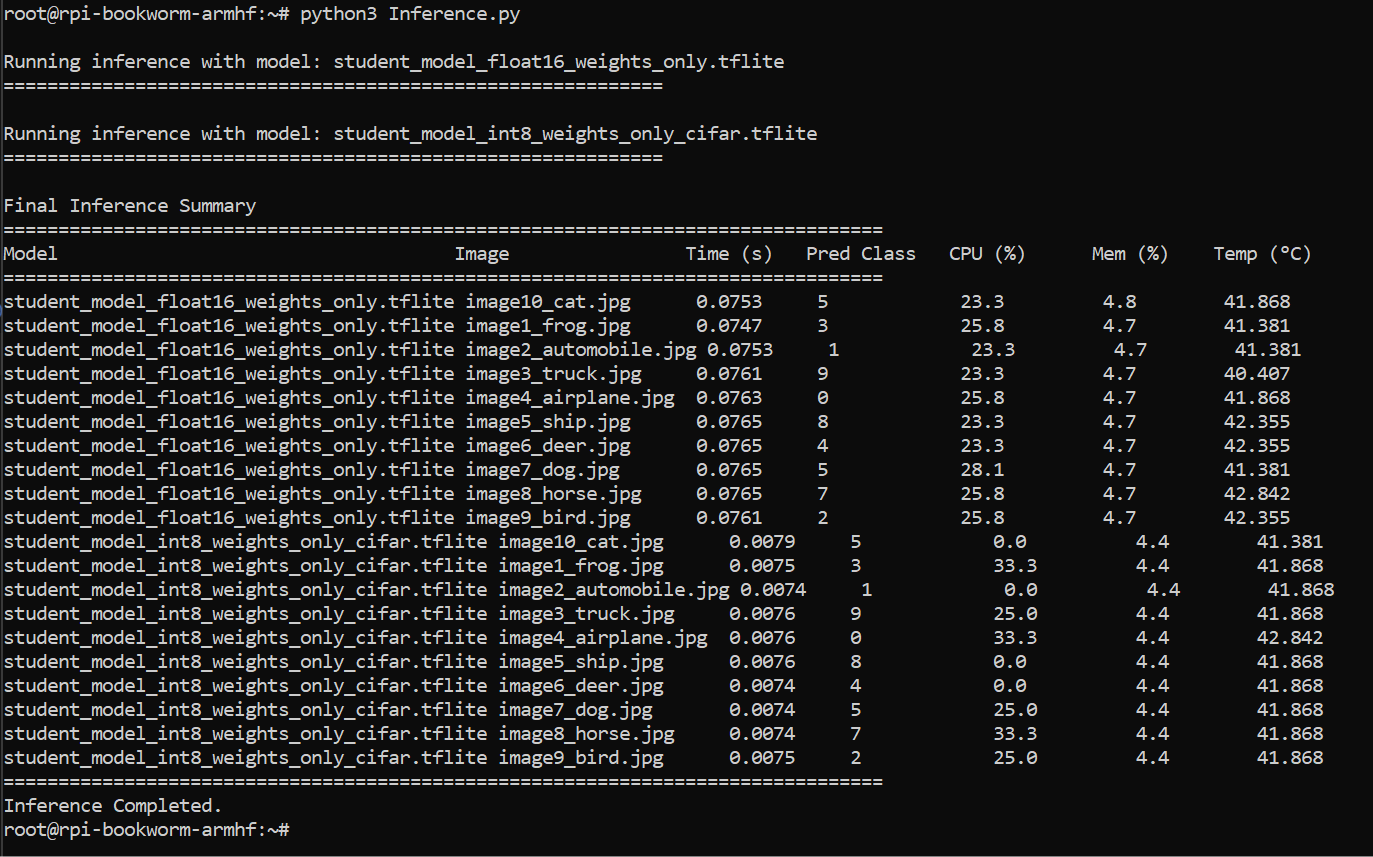

# Your Answers:

## 1. Inference Time

**Question:** Compare the execution times for different models. Which model runs faster? How does quantization affect speed?

**Answer:**  
The INT8 quantized model ran much faster than the FP16 model. From the summary table, the FP16 model took about 0.074–0.077 s per image, while the INT8 model took about 0.0074–0.0079 s per image. This means the INT8 model was roughly 10× faster on the Raspberry Pi. This result makes sense because the INT8 model uses fewer bits, and integer computations are generally more efficient. In conclusion, quantization improved inference speed significantly because INT8 arithmetic requires less computation and memory bandwidth than FP16 on the Raspberry Pi.

---

## 2. CPU and Memory Usage

**Question:** Observe CPU and memory utilization before and after inference. Do different models show significant differences in resource consumption?


**Answer:**  
The two models showed only modest differences in CPU and memory usage. However, the quantized INT8 model had slightly lower memory usage overall, and lower CPU usage in most cases compared to the FP16 model. The FP16 model used around 4.7–4.8% memory, while the INT8 model used around 4.4% memory. CPU readings varied across runs, so there was not a perfectly consistent trend, but both models stayed within a similar low-to-moderate CPU range. In most cases, the FP16 model did show slightly higher CPU usage. Temperature also stayed very similar, around 41–43°C, and neither model caused a major increase in temperature during the inference runs.

---

## 3. Prediction Consistency

**Question:** Look at the predicted classes. Are the models making consistent predictions across different images?

**Answer:** 
The two models produced the same predicted class for all 10 images, so their predictions were fully consistent with each other. Most predictions matched the expected image categories, although a small number of images were misclassified. More specifically, both models got 8 out of 10 predictions correct. Both models predicted the cat image as dog and the frog image as cat. The rest of the predictions were accurate. Overall, quantization did not change the model’s prediction behavior on these sample images, which suggests that compression preserved the student model’s inference quality well.